<font color=#009afa size=50>DAT-6002 - Fundamentals of Artificial Intelligence</font><br>
<font size=50>WRIT1 Part 2 - Neural Networks</font><br>
<font size=20 color=#00c382>From Scratch MLP - Bank Data</font><br>

|**Assessment Code:** |WRIT1|
|---|---|
|**Author:**|Tom Rowan|
|**Course:**|DAT6002_S2_25|
|**Course Tutor:**|Imtiaz Hussain Khan, PhD|


**Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.**

https://archive.ics.uci.edu/dataset/222/bank+marketing

---

# Initialise Notebook

In [160]:
# Install Requirements Using Pip
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [161]:
# Standard Libraries
import sys
import time
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Pycountry 
import pycountry

# GeoPy
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# IPython Display 
from IPython.display import HTML

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [162]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [163]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow'):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}')

### Check for Internet Access

In [164]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [165]:
internet_required = False

In [166]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


---
# Load the Dataset

In [181]:
if online:
    # Fetch the dataset from the Internet
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')
else:
    # Load the dataset from local file
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')

Now it is necessary to split the input dataset into two parts - testing and training data

In [182]:
# Split data frame into 80/20
df_train = df.sample(frac = 0.8)
# Creating dataframe with rest of the 20% values
df_test = df.drop(df_train.index)

In [183]:
# Split datasets into X (features) and y (labels)
df_X_train = df_train.drop(columns='y')
df_y_train = df_train['y']

df_X_test = df_test.drop(columns='y')
df_y_test = df_test['y']

# Convert to numpy arrays
X_np_train = df_X_train.to_numpy()
y_np_train = df_y_train.to_numpy().reshape(-1,1)

X_np_test = df_X_test.to_numpy()
y_np_test = df_y_test.to_numpy().reshape(-1,1)


# Neural Network

"Construct a three-layer feedforward neural network consisting of N input neurons, 10 hidden neurons, and M output neuron(s)."

In [170]:
# Define layer sizes
input_neurons = X_np_train.shape[1] # Set dynamically based on the input dataset
hidden_neurons = 10                 # 10 hidden neurons, per assessment specification
output_neurons = 1                  # This is a binary classification problem, which implies 1 output neuron

# Initialize Weights with small random numbers
# 
#   input_neurons --> weights_1 --> hidden_neurons --> weights_2 --> output_neurons
#                     biases_1                         biases_2
#
np.random.seed(67)

weights_1 = np.random.randn(input_neurons, hidden_neurons) * 0.01
biases_1 = np.zeros((1, hidden_neurons))

weights_2 = np.random.randn(hidden_neurons, output_neurons) * 0.01
biases_2 = np.zeros((1, output_neurons))

In [171]:
print_output("No Input Layer Neurons", input_neurons)
print_output("No Input Layer Neurons", hidden_neurons)
print_output("No Output Layer Neurons", output_neurons)

No Input Layer Neurons: 44
No Input Layer Neurons: 10
No Output Layer Neurons: 1


Z1​=X⋅W1​+b1​

In a neural network, the forward pass consists of two main operations per layer:

    Linear Transformation: Z=X⋅W+b

    Activation Function: A=σ(Z)

For a binary classification task like this, the Sigmoid function is the standard choice for the output layer because it squashes any input into a value between 0 and 1, which we can interpret as a probability.  (citation)

In [172]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    # Derivative of sigmoid is a * (1 - a)
    return a * (1 - a)

# Generic version to allow replacement
def act_func(z):
    return sigmoid(z)

def act_func_deriv(a):
    return sigmoid_derivative(a)

In [173]:
def forward_propagation(X, W1, b1, W2, b2):
    # Layer 1 (Hidden Layer)
    # Z1 shape: (m, hidden_neurons)
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    
    # Layer 2 (Output Layer)
    # Z2 shape: (m, 1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    
    # We return everything
    return Z1, A1, Z2, A2

To know how "wrong" the network is, we use Binary Cross-Entropy Loss (also called Log Loss). This is much more effective for classification than Mean Squared Error.
Loss=−m1​∑[y⋅log(y^​)+(1−y)⋅log(1−y^​)]

In [174]:
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    # Adding a tiny epsilon (1e-15) prevents log(0) which would result in NaN
    loss = -1/m * np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))
    return loss

In [175]:
def back_propagation(X, y, Z1, A1, Z2, A2, W1, W2):
    m = X.shape[0]
    
    # 1. Output Layer Gradients
    dZ2 = A2 - y  # Error signal at the end
    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
    
    # 2. Hidden Layer Gradients
    # We pass the error back through W2 and then through the Sigmoid derivative
    dZ1 = np.dot(dZ2, W2.T) * sigmoid_derivative(A1)
    dW1 = (1/m) * np.dot(X.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
    
    return dW1, db1, dW2, db2

In [176]:
def train_network(X, y, epochs=1000, learning_rate=0.1):
    # 1. Initialize Weights with the Seed (Reproduction)
    np.random.seed(42)
    input_size = X.shape[1]
    hidden_size = 16
    output_size = 1
    
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))
    
    loss_history = []

    for i in range(epochs):
        # 2. Forward Propagation
        Z1, A1, Z2, A2 = forward_propagation(X, W1, b1, W2, b2)
        
        # 3. Compute and store Loss
        current_loss = compute_loss(y, A2)
        loss_history.append(current_loss)
        
        # 4. Backpropagation (Calculate Gradients)
        dW1, db1, dW2, db2 = back_propagation(X, y, Z1, A1, Z2, A2, W1, W2)
        
        # 5. Gradient Descent (Update Weights)
        # New Weight = Old Weight - (Learning Rate * Gradient)
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        
        # 6. Print progress every 100 epochs
        if i % 100 == 0:
            print(f"Epoch {i}: Loss {current_loss:.4f}")
            
    return W1, b1, W2, b2, loss_history

In [177]:
# Start the training!
W1_final, b1_final, W2_final, b2_final, history = train_network(X_np_train, y_np_train, epochs=2000, learning_rate=0.5)

# Final Accuracy Check
_, _, _, final_preds = forward_propagation(X_np_train, W1_final, b1_final, W2_final, b2_final)
final_accuracy = np.mean((final_preds > 0.5) == y_np_train) * 100
print(f"\nFinal Accuracy: {final_accuracy:.2f}%")

Epoch 0: Loss 0.6932
Epoch 100: Loss 0.3529
Epoch 200: Loss 0.3471
Epoch 300: Loss 0.3407
Epoch 400: Loss 0.3340
Epoch 500: Loss 0.3278
Epoch 600: Loss 0.3224
Epoch 700: Loss 0.3181
Epoch 800: Loss 0.3145
Epoch 900: Loss 0.3116
Epoch 1000: Loss 0.3093
Epoch 1100: Loss 0.3074
Epoch 1200: Loss 0.3058
Epoch 1300: Loss 0.3046
Epoch 1400: Loss 0.3036
Epoch 1500: Loss 0.3028
Epoch 1600: Loss 0.3022
Epoch 1700: Loss 0.3017
Epoch 1800: Loss 0.3013
Epoch 1900: Loss 0.3009

Final Accuracy: 89.41%


In [178]:
# After training...
# Use the final weights to predict on the TEST set
_, _, _, test_probs = forward_propagation(X_np_test, W1_final, b1_final, W2_final, b2_final)

# Convert probabilities to 0 or 1
test_preds = (test_probs > 0.5).astype(int)

# Calculate Accuracy
test_accuracy = np.mean(test_preds == y_np_test) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 88.87%


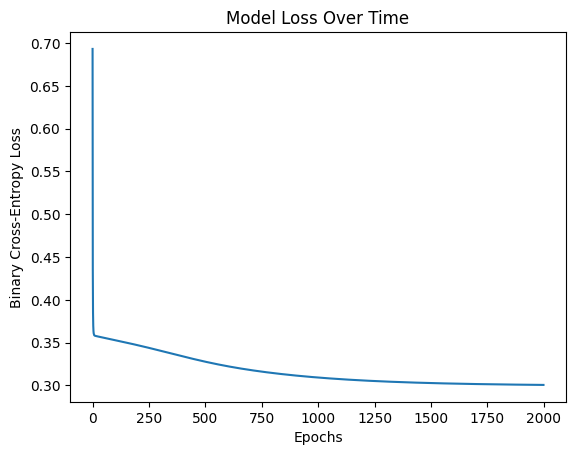

In [179]:
import matplotlib.pyplot as plt

plt.plot(history)
plt.title('Model Loss Over Time')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy Loss')
plt.show()

In [180]:
sys.exit('Stopping notebook run here.')   

SystemExit: Stopping notebook run here.

---